# SIT307 — 11.1 HD Task: Machine Learning Research

**Student name:** Ravishan Wedisinghe  
**Student ID:** s224740606

## Part 1: Dataset Inspection

This section checks the dataset size, column names, missing values,
repeated rows and the number of examples in each target class.

In [1]:
import pandas as pd

data = pd.read_csv("heart_3.csv")

print("Rows and columns:", data.shape)
print("Columns:")
for column in data.columns:
    print("-", column)
print("Missing values:", data.isna().sum().sum())
print("Repeated rows:", data.duplicated().sum())
print("Target counts:")
print(data["target"].value_counts())

Rows and columns: (1025, 14)
Columns:
- age
- sex
- cp
- trestbps
- chol
- fbs
- restecg
- thalach
- exang
- oldpeak
- slope
- ca
- thal
- target
Missing values: 0
Repeated rows: 723
Target counts:
target
1    526
0    499
Name: count, dtype: int64


### Dataset observations

- The dataset has 1,025 rows and 14 columns.
- There are no missing values.
- The target classes contain 526 and 499 rows.
- There are 723 repeated rows. I will keep the original data for the
  reproduction and examine the effect of repeats separately.

In [2]:
X = data.drop(columns=["target"])
y = data["target"]

print("Input data:", X.shape)
print("Target data:", y.shape)
print("Input columns:", X.columns.tolist())

Input data: (1025, 13)
Target data: (1025,)
Input columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


### 1.2 Training and Test Split

The paper does not clearly state the split ratio or random seed.
I use an 80% training and 20% test split with a fixed random seed
so the experiment can be repeated. The split keeps both target classes
in similar proportions.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training inputs:", X_train.shape)
print("Testing inputs:", X_test.shape)
print("Training target counts:")
print(y_train.value_counts())
print("Testing target counts:")
print(y_test.value_counts())

Training inputs: (820, 13)
Testing inputs: (205, 13)
Training target counts:
target
1    421
0    399
Name: count, dtype: int64
Testing target counts:
target
1    105
0    100
Name: count, dtype: int64


 202 of the 205 test rows also appear in the training data. This overlap may make the model results look better than they would on new records. I will report this limitation when comparing my results with the paper.

### 1.3 Check for Repeated Records Across the Split

The dataset contains repeated rows. I check whether identical records appear in both the training and test sets because this could make test results look better than they really are.

In [4]:
train_rows = X_train.copy()
train_rows["target"] = y_train

test_rows = X_test.copy()
test_rows["target"] = y_test

shared_rows = test_rows.merge(train_rows.drop_duplicates(), how="inner")

print("Test rows also found in training:", len(shared_rows))
print("Total test rows:", len(test_rows))

Test rows also found in training: 202
Total test rows: 205


### 1.4 Feature Types and Preprocessing

Some features are measurements such as age and cholesterol. Others are category codes such as chest pain type. I will prepare these feature types separately. Any preprocessing learned from the data will be fitted using the training set only.

In [5]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

categorical_features = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Total features:", len(numeric_features) + len(categorical_features))

Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Total features: 13


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("numbers", StandardScaler(), numeric_features),
        ("categories", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_features)
    ]
)

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print("Prepared training data:", X_train_ready.shape)
print("Prepared test data:", X_test_ready.shape)

Prepared training data: (820, 30)
Prepared test data: (205, 30)


### 1.5 Logistic Regression

I train Logistic Regression as the first model from the paper. The paper does not give all model settings so I use scikit learn's default settings with a higher iteration limit to allow the model to finish training.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_ready, y_train)

lr_predictions = lr_model.predict(X_test_ready)
lr_probabilities = lr_model.predict_proba(X_test_ready)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, lr_predictions), 4))
print("Precision:", round(precision_score(y_test, lr_predictions), 4))
print("Recall:", round(recall_score(y_test, lr_predictions), 4))
print("F1 Score:", round(f1_score(y_test, lr_predictions), 4))
print("AUC:", round(roc_auc_score(y_test, lr_probabilities), 4))

Accuracy: 0.8732
Precision: 0.8559
Recall: 0.9048
F1 Score: 0.8796
AUC: 0.9445


### 1.6 Naive Bayes

I train a Gaussian Naive Bayes model using the same prepared training and test data. I evaluate it with the same five metrics so the models can be compared.

In [8]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_ready, y_train)

nb_predictions = nb_model.predict(X_test_ready)
nb_probabilities = nb_model.predict_proba(X_test_ready)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, nb_predictions), 4))
print("Precision:", round(precision_score(y_test, nb_predictions), 4))
print("Recall:", round(recall_score(y_test, nb_predictions), 4))
print("F1 Score:", round(f1_score(y_test, nb_predictions), 4))
print("AUC:", round(roc_auc_score(y_test, nb_probabilities), 4))

Accuracy: 0.8244
Precision: 0.8108
Recall: 0.8571
F1 Score: 0.8333
AUC: 0.8708


### 1.7 K-Nearest Neighbours (KNN)

I train a KNN model using the same prepared data. The paper does not clearly state the number of neighbours so I use five neighbours and record this as an assumption.

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_ready, y_train)

knn_predictions = knn_model.predict(X_test_ready)
knn_probabilities = knn_model.predict_proba(X_test_ready)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, knn_predictions), 4))
print("Precision:", round(precision_score(y_test, knn_predictions), 4))
print("Recall:", round(recall_score(y_test, knn_predictions), 4))
print("F1 Score:", round(f1_score(y_test, knn_predictions), 4))
print("AUC:", round(roc_auc_score(y_test, knn_probabilities), 4))

Accuracy: 0.8634
Precision: 0.8468
Recall: 0.8952
F1 Score: 0.8704
AUC: 0.9698


### 1.8 Decision Tree

I train a Decision Tree using the same prepared data and test split. The paper does not give clear tree settings so I use the default settings with a fixed random seed.

In [10]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_ready, y_train)

dt_predictions = dt_model.predict(X_test_ready)
dt_probabilities = dt_model.predict_proba(X_test_ready)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, dt_predictions), 4))
print("Precision:", round(precision_score(y_test, dt_predictions), 4))
print("Recall:", round(recall_score(y_test, dt_predictions), 4))
print("F1 Score:", round(f1_score(y_test, dt_predictions), 4))
print("AUC:", round(roc_auc_score(y_test, dt_probabilities), 4))

Accuracy: 0.9854
Precision: 1.0
Recall: 0.9714
F1 Score: 0.9855
AUC: 0.9857


### 1.9 Random Forest

I train a Random Forest using the same prepared data and test split. I use 100 trees and a fixed random seed because the paper does not clearly state these settings.

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_ready, y_train)

rf_predictions = rf_model.predict(X_test_ready)
rf_probabilities = rf_model.predict_proba(X_test_ready)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, rf_predictions), 4))
print("Precision:", round(precision_score(y_test, rf_predictions), 4))
print("Recall:", round(recall_score(y_test, rf_predictions), 4))
print("F1 Score:", round(f1_score(y_test, rf_predictions), 4))
print("AUC:", round(roc_auc_score(y_test, rf_probabilities), 4))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
AUC: 1.0


### 1.10 XGBoost

I train an XGBoost model using the same prepared data and test split. The paper does not clearly give all settings so I use 100 trees and a fixed random seed. I will interpret the results with care because many test records also appear in training.

In [12]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train_ready, y_train)

xgb_predictions = xgb_model.predict(X_test_ready)
xgb_probabilities = xgb_model.predict_proba(X_test_ready)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, xgb_predictions), 4))
print("Precision:", round(precision_score(y_test, xgb_predictions), 4))
print("Recall:", round(recall_score(y_test, xgb_predictions), 4))
print("F1 Score:", round(f1_score(y_test, xgb_predictions), 4))
print("AUC:", round(roc_auc_score(y_test, xgb_probabilities), 4))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
AUC: 1.0


### 1.11 Five-Fold Stacking Ensemble

I combine the six classifiers using five fold stacking. I use Logistic Regression as the final model because the paper does not clearly specify its final model. Each base model prepares its data within the training folds. I evaluate the finished ensemble on the same test set used above.

In [13]:
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

stack_model = StackingClassifier(
    estimators=[
        ("lr", make_pipeline(clone(preprocessor),
                             LogisticRegression(max_iter=1000, random_state=42))),
        ("nb", make_pipeline(clone(preprocessor), GaussianNB())),
        ("knn", make_pipeline(clone(preprocessor),
                              KNeighborsClassifier(n_neighbors=5))),
        ("dt", make_pipeline(clone(preprocessor),
                             DecisionTreeClassifier(random_state=42))),
        ("rf", make_pipeline(clone(preprocessor),
                             RandomForestClassifier(n_estimators=100, random_state=42))),
        ("xgb", make_pipeline(clone(preprocessor),
                              XGBClassifier(n_estimators=100, random_state=42,
                                            eval_metric="logloss")))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method="predict_proba"
)

stack_model.fit(X_train, y_train)

stack_predictions = stack_model.predict(X_test)
stack_probabilities = stack_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, stack_predictions), 4))
print("Precision:", round(precision_score(y_test, stack_predictions), 4))
print("Recall:", round(recall_score(y_test, stack_predictions), 4))
print("F1 Score:", round(f1_score(y_test, stack_predictions), 4))
print("AUC:", round(roc_auc_score(y_test, stack_probabilities), 4))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
AUC: 1.0


### 1.12 Comparison of Part 1 Results

The table compares my test results with the results reported in the paper. My test set has substantial overlap with the training set so very high scores may not show how well a model works on new records. The paper also leaves some implementation settings unclear.

In [14]:
def model_scores(name, predictions, probabilities):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "AUC": roc_auc_score(y_test, probabilities)
    }

our_results = pd.DataFrame([
    model_scores("Logistic Regression", lr_predictions, lr_probabilities),
    model_scores("Naive Bayes", nb_predictions, nb_probabilities),
    model_scores("KNN", knn_predictions, knn_probabilities),
    model_scores("Decision Tree", dt_predictions, dt_probabilities),
    model_scores("Random Forest", rf_predictions, rf_probabilities),
    model_scores("XGBoost", xgb_predictions, xgb_probabilities),
    model_scores("Stacking", stack_predictions, stack_probabilities)
])

display(our_results.round(4))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8732,0.8559,0.9048,0.8796,0.9445
1,Naive Bayes,0.8244,0.8108,0.8571,0.8333,0.8708
2,KNN,0.8634,0.8468,0.8952,0.8704,0.9698
3,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
4,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
5,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
6,Stacking,1.0000,1.0000,1.0000,1.0000,1.0000


### 1.13 Comparison with the Published Paper
Compare the seven models using accuracy, precision, recall, F1 score and AUC. Interpret unusually high scores in light of the repeated records found in this dataset.

In [15]:
paper_results = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Naive Bayes", "KNN",
        "Decision Tree", "Random Forest", "XGBoost", "Stacking"
    ],
    "Accuracy": [0.8439, 0.8439, 0.8585, 0.9268, 0.9268, 0.9073, 0.9853],
    "Precision": [0.8196, 0.8250, 0.8648, 0.9702, 0.9130, 0.9174, 1.0000],
    "Recall": [0.9090, 0.9000, 0.8727, 0.8909, 0.9545, 0.9090, 0.9727],
    "F1": [0.8620, 0.8608, 0.8687, 0.9289, 0.9333, 0.9132, 0.9861],
    "AUC": [0.9204, 0.9185, 0.9304, 0.9702, 0.9734, 0.9830, 0.9880]
})

comparison = our_results.merge(
    paper_results, on="Model", suffixes=(" (ours)", " (paper)")
)
display(comparison.round(4))

,Model,Accuracy (ours),Precision (ours),Recall (ours),F1 (ours),AUC (ours),Accuracy (paper),Precision (paper),Recall (paper),F1 (paper),AUC (paper)
0,Logistic Regression,0.8732,0.8559,0.9048,0.8796,0.9445,0.8439,0.8196,0.9090,0.8620,0.9204
1,Naive Bayes,0.8244,0.8108,0.8571,0.8333,0.8708,0.8439,0.8250,0.9000,0.8608,0.9185
2,KNN,0.8634,0.8468,0.8952,0.8704,0.9698,0.8585,0.8648,0.8727,0.8687,0.9304
3,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857,0.9268,0.9702,0.8909,0.9289,0.9702
4,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0.9268,0.9130,0.9545,0.9333,0.9734
5,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,0.9073,0.9174,0.9090,0.9132,0.9830
6,Stacking,1.0000,1.0000,1.0000,1.0000,1.0000,0.9853,1.0000,0.9727,0.9861,0.9880


My results differ from the published results. Random Forest, XGBoost and Stacking achieved 100% on my test set. However 202 of the 205 test rows also appeared in the training set. These scores may therefore be too optimistic. The paper does not give enough detail to recreate every setting exactly.

# Part 2: Stacking with Duplicate-Safe Evaluation

## Limitation and motivation

The selected paper reports 98.53% accuracy for its stacking ensemble [1]. In my Part 1 reproduction, the dataset contained 1,025 rows including 723 exact duplicate rows. There were 302 unique feature records. After my random training and test split 202 of the 205 test rows also appeared in training. This overlap may make the measured performance too optimistic.

This finding concerns my reproduction. It does not establish that the paper’s authors used an overlapping split. Without patient identifiers I also cannot confirm that the 302 unique records represent 302 different patients.

My proposed solution addresses exact record overlap and investigates whether feature engineering, regularisation, parameter tuning and threshold selection can improve performance under a cleaner evaluation.

## Proposed method

The method contains five components:

1. **Duplicate removal and repeated validation:** Remove exact duplicate records, check for conflicting labels and evaluate all models using the same repeated stratified five fold splits.
2. **Feature engineering:** Add three derived features based on maximum heart rate and age, the vessel count feature and the interaction between oldpeak and slope.
3. **Parameter tuning:** Use three fold grid search within each outer training fold to select base model settings using AUC.
4. **Regularised stacking:** Combine a modified set of base models using a Logistic Regression final model with regularisation.
5. **Threshold selection:** Select a threshold using training-derived predictions aiming for at least 90% sensitivity during threshold validation. This does not guarantee 90% sensitivity on unseen data.

## Evaluation and limitations

I compare the original stacking design, individual baseline models, and several variants of the proposed method. These comparisons help examine how the changes affect performance, although some variants change more than one element.

I report Accuracy, Precision, Recall, F1 Score and AUC, together with additional measures and statistical comparisons. The outer test folds are excluded from model fitting, parameter tuning, and threshold selection.

However the current implementation selects parameters before generating the base models’ out of fold predictions. Threshold validation also cross validates the final model on an existing prediction matrix rather than refitting the complete stack. Therefore the internal validation is not fully nested, and its training validation estimates may be optimistic.

In [16]:
# ---- 2.0 Setup ---------------------------------------------------------
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     StratifiedShuffleSplit, GridSearchCV, cross_val_predict)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, brier_score_loss, matthews_corrcoef,
                            roc_curve, confusion_matrix)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:                      # fallback so the notebook still runs
    HAS_XGB = False
    print("xgboost not found: GradientBoostingClassifier is used instead.")

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", None)

# ---- Configuration (everything needed to reproduce the results) ---------
DATA_PATH   = "heart_3.csv"
SEED        = 42
N_SPLITS    = 5
N_REPEATS   = 5
TARGET_SENS = 0.90
OUT_DIR     = "part2_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED)

In [17]:
# ---- 2.1 Data preparation ---------------------------------------------
raw = pd.read_csv(DATA_PATH)
df  = raw.drop_duplicates().reset_index(drop=True)       # one row per unique patient record

print("Raw rows:", len(raw), "| duplicate rows:", raw.duplicated().sum(), "| unique rows:", len(df))
print("Unique-row class counts:\n", df["target"].value_counts().to_string())

# identical feature rows must share a label otherwise de duplication would hide label noise
conflicts = (raw.groupby(list(raw.columns.drop("target")))["target"].nunique() > 1).sum()
print("Feature groups with conflicting labels:", conflicts)

X = df.drop(columns="target")
y = df["target"].values

NUM = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CAT = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

Raw rows: 1025 | duplicate rows: 723 | unique rows: 302
Unique-row class counts:
 target
1    164
0    138
Feature groups with conflicting labels: 0


### 2.2 Quantifying the leakage effect (motivation)

I run the paper style six model stack under two protocols: (a) repeated random 80/20 splits on the **raw** 1,025 rows (the paper's protocol) and (b) the **clean** protocol (unique patients only). Only the evaluation protocol changes.

In [18]:
# ---- Model factories used by the paper style baseline ------------------
def boosted(**kw):
    if HAS_XGB:
        return XGBClassifier(n_estimators=100, random_state=SEED, eval_metric="logloss", **kw)
    return GradientBoostingClassifier(random_state=SEED)

def plain_pre():
    return ColumnTransformer([
        ("num", StandardScaler(), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT)])

def paper_stack():
    """Same design as Part 1: six classifiers, 5-fold stacking, logistic-regression meta-learner."""
    mk = lambda m: Pipeline([("pre", plain_pre()), ("m", m)])
    est = [("lr", mk(LogisticRegression(max_iter=1000, random_state=SEED))),
           ("nb", mk(GaussianNB())),
           ("knn", mk(KNeighborsClassifier(5))),
           ("dt", mk(DecisionTreeClassifier(random_state=SEED))),
           ("rf", mk(RandomForestClassifier(100, random_state=SEED))),
           ("xgb", mk(boosted()))]
    return StackingClassifier(est, final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
                              cv=5, stack_method="predict_proba")

def eval_split(model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    p = model.predict_proba(Xte)[:, 1]
    return accuracy_score(yte, (p >= .5).astype(int)), roc_auc_score(yte, p)

# (a) paper protocol: random 80/20 on raw rows (duplicates can cross the split)
Xr, yr = raw.drop(columns="target"), raw["target"].values
leaky = []
for tr, te in StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=0.20, random_state=SEED).split(Xr, yr):
    leaky.append(eval_split(paper_stack(), Xr.iloc[tr], yr[tr], Xr.iloc[te], yr[te]))

# (b) clean protocol: unique patients, repeated stratified CV
clean = []
for tr, te in RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=1, random_state=SEED).split(X, y):
    clean.append(eval_split(paper_stack(), X.iloc[tr], y[tr], X.iloc[te], y[te]))

leak_table = pd.DataFrame({
    "Protocol": ["Paper-style split on raw rows (duplicates leak)", "Clean protocol (unique patients, CV)"],
    "Accuracy": [np.mean([a for a, _ in leaky]), np.mean([a for a, _ in clean])],
    "Acc std":  [np.std([a for a, _ in leaky]),  np.std([a for a, _ in clean])],
    "AUC":      [np.mean([b for _, b in leaky]), np.mean([b for _, b in clean])]})
display(leak_table.round(4))
leak_table.to_csv(f"{OUT_DIR}/leakage_effect.csv", index=False)

,Protocol,Accuracy,Acc std,AUC
0,Paper-style split on raw rows (duplicates leak),0.9873,0.0114,0.9966
1,"Clean protocol (unique patients, CV)",0.8413,0.0363,0.9122


### 2.3 The LSNS pipeline

LSNS is a scikit learn style estimator. Its flags switch each component on or off which is how the ablation study is run. Inside fit() (i.e. using only the training fold):

1. optional feature engineering hr_ratio = thalach/(220-age, ca_any = ca>0, oldpeak_slope = oldpeak slope==2);
2. optional grid search (inner 3 fold CV, AUC) for each base learner;
3. out of fold probabilities from every base learner (5 fold);
4. a regularised logistic regression meta learner trained on those out of fold probabilities;
5. optional threshold: the highest threshold whose out of fold sensitivity is at least TARGET_SENS (maximises specificity under the recall constraint).

In [19]:
# ---- 2.3 LSNS implementation ------------------------------------------
def add_clinical_features(d):
    d = d.copy()
    d["hr_ratio"]      = d["thalach"] / (220 - d["age"])        # achieved vs age-predicted max heart rate
    d["ca_any"]        = (d["ca"] > 0).astype(int)              # any major vessel coloured
    d["oldpeak_slope"] = d["oldpeak"] * (d["slope"] == 2).astype(int)
    return d

def build_pre(use_fe):
    num, cat = list(NUM), list(CAT)
    if use_fe:
        num += ["hr_ratio", "oldpeak_slope"]; cat += ["ca_any"]
    pre = ColumnTransformer([("num", StandardScaler(), num),
                             ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)])
    steps = ([("fe", FunctionTransformer(add_clinical_features))] if use_fe else []) + [("pre", pre)]
    return steps

def wrap(model, use_fe):
    return Pipeline(build_pre(use_fe) + [("m", model)])

def reg_boosted():
    if HAS_XGB:
        return XGBClassifier(n_estimators=100, max_depth=2, learning_rate=0.05, subsample=0.8,
                             random_state=SEED, eval_metric="logloss")
    return GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=0.05,
                                      subsample=0.8, random_state=SEED)

def base_learners(base_set, use_fe):
    """Returns list of (name, pipeline, param_grid). Grid keys use the pipeline step name 'm'."""
    if base_set == "paper":
        return [("lr",  wrap(LogisticRegression(max_iter=1000, random_state=SEED), use_fe), {}),
                ("nb",  wrap(GaussianNB(), use_fe), {}),
                ("knn", wrap(KNeighborsClassifier(5), use_fe), {}),
                ("dt",  wrap(DecisionTreeClassifier(random_state=SEED), use_fe), {}),
                ("rf",  wrap(RandomForestClassifier(100, random_state=SEED), use_fe), {}),
                ("xgb", wrap(boosted(), use_fe), {})]
    # regularised, diverse set for small data
    gb_grid = ({"m__n_estimators": [50, 150], "m__learning_rate": [0.03, 0.1]})
    return [("lr",  wrap(LogisticRegression(C=0.3, max_iter=2000, random_state=SEED), use_fe),
             {"m__C": [0.03, 0.1, 0.3, 1, 3]}),
            ("svm", wrap(SVC(C=1, probability=True, random_state=SEED), use_fe),
             {"m__C": [0.3, 1, 3], "m__gamma": ["scale", 0.01]}),
            ("rf",  wrap(RandomForestClassifier(200, min_samples_leaf=3, max_depth=5, random_state=SEED), use_fe),
             {"m__min_samples_leaf": [2, 4, 8], "m__max_depth": [3, 6]}),
            ("gb",  wrap(reg_boosted(), use_fe), gb_grid),
            ("nb",  wrap(GaussianNB(), use_fe), {})]

class LSNS(ClassifierMixin, BaseEstimator):
    def __init__(self, use_fe=True, base_set="reg", tune=True, threshold_mode="sens",
                 target_sens=TARGET_SENS, meta_C=0.5, random_state=SEED):
        self.use_fe = use_fe; self.base_set = base_set; self.tune = tune
        self.threshold_mode = threshold_mode; self.target_sens = target_sens
        self.meta_C = meta_C; self.random_state = random_state

    def fit(self, X, y):
        y = np.asarray(y); self.classes_ = np.array([0, 1])
        skf = StratifiedKFold(5, shuffle=True, random_state=self.random_state)
        self.models_, oof = [], []
        for name, est, grid in base_learners(self.base_set, self.use_fe):
            if self.tune and grid:
                gs = GridSearchCV(est, grid, scoring="roc_auc",
                                  cv=StratifiedKFold(3, shuffle=True, random_state=self.random_state))
                gs.fit(X, y); est = gs.best_estimator_
            oof.append(cross_val_predict(clone(est), X, y, cv=skf, method="predict_proba")[:, 1])
            self.models_.append(clone(est).fit(X, y))
        Z = np.column_stack(oof)
        self.meta_ = LogisticRegression(C=self.meta_C, max_iter=1000).fit(Z, y)
        self.threshold_ = 0.5
        if self.threshold_mode == "sens":
            zo = cross_val_predict(LogisticRegression(C=self.meta_C, max_iter=1000), Z, y,
                                   cv=skf, method="predict_proba")[:, 1]
            ok = [t for t in np.arange(0.05, 0.96, 0.01)
                  if recall_score(y, (zo >= t).astype(int)) >= self.target_sens]
            self.threshold_ = float(max(ok)) if ok else 0.5
        return self

    def predict_proba(self, X):
        Z = np.column_stack([m.predict_proba(X)[:, 1] for m in self.models_])
        p = self.meta_.predict_proba(Z)[:, 1]
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.threshold_).astype(int)

### 2.4 Experimental protocol

* **Data:** 302 unique patient records (no duplicates so no train/test leakage is possible).
* **Validation:** repeated stratified 5 fold CV, N_REPEATS repeats (every model sees identical folds). All tuning and threshold selection happen inside each training fold (nested).
* **Metrics:** Accuracy, Precision, Recall, F1, AUC (required) plus Specificity, MCC, Brier score and Specificity at ≥90% sensitivity.
* **Compared models:** the paper style stack (Part 1 design), Logistic Regression, Random Forest, the ablation variants and full LSNS.

In [20]:
# ---- 2.5 Models compared (ablation ladder) ----------------------------
MODELS = {
    "LogReg (baseline)":            lambda: wrap(LogisticRegression(max_iter=1000, random_state=SEED), False),
    "RandomForest (baseline)":      lambda: wrap(RandomForestClassifier(100, random_state=SEED), False),
    "Paper-style stack":            paper_stack,
    "A1: + clinical features":      lambda: LSNS(use_fe=True,  base_set="paper", tune=False, threshold_mode=None, meta_C=1.0),
    "A2: + regularised base set":   lambda: LSNS(use_fe=True,  base_set="reg",   tune=False, threshold_mode=None),
    "A3: + nested tuning":          lambda: LSNS(use_fe=True,  base_set="reg",   tune=True,  threshold_mode=None),
    "LSNS (full, + sens. threshold)": lambda: LSNS(use_fe=True, base_set="reg",  tune=True,  threshold_mode="sens"),
}
FULL = "LSNS (full, + sens. threshold)"

def spec_at_sens(y_true, p, sens=TARGET_SENS):
    fpr, tpr, _ = roc_curve(y_true, p)
    return float(np.max(1 - fpr[tpr >= sens]))

def fold_metrics(y_true, p, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"Accuracy": accuracy_score(y_true, pred),
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall": recall_score(y_true, pred),
            "F1": f1_score(y_true, pred),
            "AUC": roc_auc_score(y_true, p),
            "Specificity": tn / (tn + fp),
            "MCC": matthews_corrcoef(y_true, pred),
            "Brier": brier_score_loss(y_true, p),
            "Spec@90Sens": spec_at_sens(y_true, p)}

outer = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
rows, preds = [], []                       # per-fold metrics, per-sample predictions
t0 = time.time()
for k, (tr, te) in enumerate(outer.split(X, y)):
    for name, make in MODELS.items():
        m = make().fit(X.iloc[tr], y[tr])
        p = m.predict_proba(X.iloc[te])[:, 1]
        thr = getattr(m, "threshold_", 0.5)
        pred = (p >= thr).astype(int)
        rows.append({"Model": name, "fold": k, **fold_metrics(y[te], p, pred)})
        preds.append(pd.DataFrame({"Model": name, "fold": k, "idx": te, "y": y[te], "p": p, "pred": pred}))
    print(f"fold {k+1}/{N_SPLITS*N_REPEATS} done ({time.time()-t0:.0f}s)", end="\r")

fold_df  = pd.DataFrame(rows)
pred_df  = pd.concat(preds, ignore_index=True)
fold_df.to_csv(f"{OUT_DIR}/per_fold_metrics.csv", index=False)
pred_df.to_csv(f"{OUT_DIR}/per_sample_predictions.csv", index=False)
print("\nFinished in", round(time.time() - t0), "seconds")

fold 25/25 done (721s)
Finished in 722 seconds


### 2.6 Results (mean ± std over outer test folds)

In [21]:
METRICS = ["Accuracy", "Precision", "Recall", "F1", "AUC", "Specificity", "MCC", "Brier", "Spec@90Sens"]
order = list(MODELS.keys())
mean_t = fold_df.groupby("Model")[METRICS].mean().loc[order]
std_t  = fold_df.groupby("Model")[METRICS].std().loc[order]
summary = mean_t.round(3).astype(str) + " ± " + std_t.round(3).astype(str)
display(summary)
mean_t.round(4).to_csv(f"{OUT_DIR}/summary_mean.csv")
summary.to_csv(f"{OUT_DIR}/summary_mean_std.csv")

,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC,Brier,Spec@90Sens
Model,,,,,,,,,
LogReg (baseline),0.845 ± 0.041,0.845 ± 0.057,0.883 ± 0.064,0.861 ± 0.035,0.914 ± 0.03,0.8 ± 0.085,0.692 ± 0.085,0.116 ± 0.02,0.772 ± 0.087
RandomForest (baseline),0.821 ± 0.036,0.832 ± 0.053,0.849 ± 0.069,0.837 ± 0.034,0.909 ± 0.025,0.789 ± 0.086,0.645 ± 0.071,0.124 ± 0.014,0.755 ± 0.07
Paper-style stack,0.832 ± 0.036,0.839 ± 0.056,0.863 ± 0.064,0.848 ± 0.032,0.908 ± 0.027,0.796 ± 0.089,0.667 ± 0.073,0.121 ± 0.017,0.769 ± 0.076
A1: + clinical features,0.836 ± 0.044,0.839 ± 0.051,0.869 ± 0.077,0.851 ± 0.043,0.909 ± 0.028,0.797 ± 0.078,0.676 ± 0.088,0.12 ± 0.02,0.778 ± 0.082
A2: + regularised base set,0.842 ± 0.036,0.838 ± 0.049,0.885 ± 0.065,0.859 ± 0.033,0.913 ± 0.026,0.791 ± 0.081,0.687 ± 0.073,0.118 ± 0.017,0.782 ± 0.062
A3: + nested tuning,0.839 ± 0.034,0.836 ± 0.05,0.883 ± 0.063,0.856 ± 0.03,0.914 ± 0.026,0.787 ± 0.082,0.68 ± 0.069,0.118 ± 0.017,0.777 ± 0.068
"LSNS (full, + sens. threshold)",0.837 ± 0.035,0.823 ± 0.046,0.898 ± 0.064,0.856 ± 0.031,0.914 ± 0.026,0.765 ± 0.079,0.678 ± 0.071,0.118 ± 0.017,0.777 ± 0.068


### 2.7 Statistical comparison

Fold scores from repeated CV overlap in their training sets so the ordinary paired t test is too optimistic. I report (i) the paired **Wilcoxon signed rank test** and (ii) the **Nadeau Bengio corrected resampled t test**, with Holm correction across the baselines, for the full LSNS against each other model.

In [22]:
def corrected_t(d, n_train, n_test):
    d = np.asarray(d); k = len(d)
    var = d.var(ddof=1)
    if var == 0: return 0.0, 1.0
    t = d.mean() / np.sqrt((1 / k + n_test / n_train) * var)
    return t, 2 * stats.t.sf(abs(t), k - 1)

def holm(pvals):
    p = np.asarray(pvals); order = np.argsort(p); adj = np.empty_like(p); run = 0
    for rank, i in enumerate(order):
        run = max(run, (len(p) - rank) * p[i]); adj[i] = min(1, run)
    return adj

n_test  = len(y) // N_SPLITS
n_train = len(y) - n_test
TEST_METRICS = ["Accuracy", "Recall", "Specificity", "F1", "AUC", "Brier", "Spec@90Sens"]

stat_rows = []
for metric in TEST_METRICS:
    ref = fold_df[fold_df.Model == FULL].sort_values("fold")[metric].values
    pw, pc, names, diffs = [], [], [], []
    for other in [m for m in order if m != FULL]:
        oth = fold_df[fold_df.Model == other].sort_values("fold")[metric].values
        d = ref - oth
        try: pw.append(stats.wilcoxon(ref, oth).pvalue)
        except ValueError: pw.append(1.0)
        pc.append(corrected_t(d, n_train, n_test)[1]); names.append(other); diffs.append(d.mean())
    pw_h, pc_h = holm(pw), holm(pc)
    for i, o in enumerate(names):
        stat_rows.append({"Metric": metric, "LSNS vs": o, "Mean diff": diffs[i],
                          "Wilcoxon p (Holm)": pw_h[i], "Corrected-t p (Holm)": pc_h[i]})

stat_df = pd.DataFrame(stat_rows)
display(stat_df.round(4))
stat_df.to_csv(f"{OUT_DIR}/statistical_tests.csv", index=False)
print("For Brier score a NEGATIVE mean difference means LSNS is better; for other metrics positive is better.")

,Metric,LSNS vs,Mean diff,Wilcoxon p (Holm),Corrected-t p (Holm)
0,Accuracy,LogReg (baseline),-0.0079,0.8876,1.0000
1,Accuracy,RandomForest (baseline),0.0158,0.0766,1.0000
2,Accuracy,Paper-style stack,0.0047,0.6248,1.0000
3,Accuracy,A1: + clinical features,0.0007,1.0000,1.0000
4,Accuracy,A2: + regularised base set,-0.0053,0.8876,1.0000
5,Accuracy,A3: + nested tuning,-0.0019,1.0000,1.0000
6,Recall,LogReg (baseline),0.0147,0.1359,1.0000
7,Recall,RandomForest (baseline),0.0487,0.0006,0.1963
8,Recall,Paper-style stack,0.0342,0.0236,0.9609
9,Recall,A1: + clinical features,0.0281,0.0386,1.0000


For Brier score a NEGATIVE mean difference means LSNS is better; for other metrics positive is better.


### 2.8 Operating-point comparison (the screening view)

Accuracy at a threshold of 0.5 is not the whole story for a screening tool. Here every model is evaluated on its pooled out of fold predictions and I report the specificity achieved when sensitivity is held to at least 90% and the sensitivity/specificity actually obtained by LSNS at its own learned threshold.

In [23]:
rows = []
for name in order:
    s = pred_df[pred_df.Model == name]
    fpr, tpr, _ = roc_curve(s.y, s.p)
    rows.append({"Model": name,
                 "Pooled AUC": roc_auc_score(s.y, s.p),
                 "Spec @ >=90% Sens": float(np.max(1 - fpr[tpr >= 0.90])),
                 "Sens (own threshold)": recall_score(s.y, s.pred),
                 "Spec (own threshold)": recall_score(1 - s.y, 1 - s.pred),
                 "Brier": brier_score_loss(s.y, s.p)})
op = pd.DataFrame(rows).set_index("Model")
display(op.round(4))
op.to_csv(f"{OUT_DIR}/operating_point.csv")

,Pooled AUC,Spec @ >=90% Sens,Sens (own threshold),Spec (own threshold),Brier
Model,,,,,
LogReg (baseline),0.9108,0.7884,0.8829,0.8000,0.1160
RandomForest (baseline),0.9044,0.7290,0.8488,0.7884,0.1245
Paper-style stack,0.9027,0.7638,0.8634,0.7957,0.1209
A1: + clinical features,0.9031,0.7594,0.8695,0.7971,0.1202
A2: + regularised base set,0.9073,0.7841,0.8854,0.7913,0.1177
A3: + nested tuning,0.9084,0.7725,0.8829,0.7870,0.1179
"LSNS (full, + sens. threshold)",0.9084,0.7725,0.8976,0.7652,0.1179


### 2.9 Figures

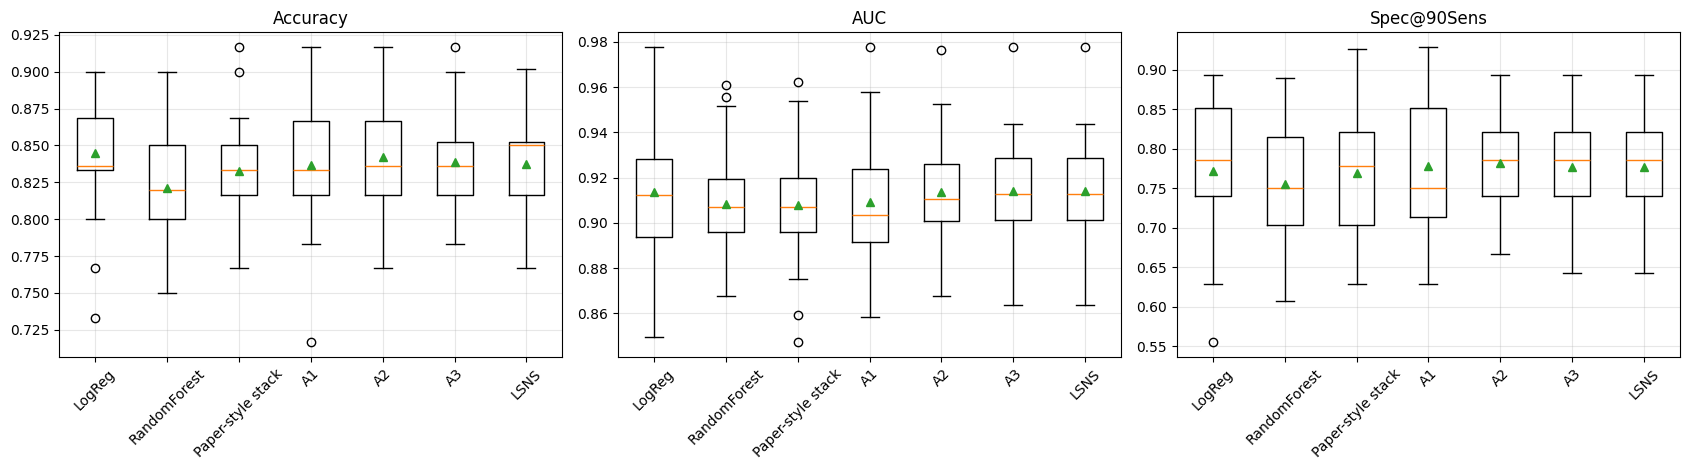

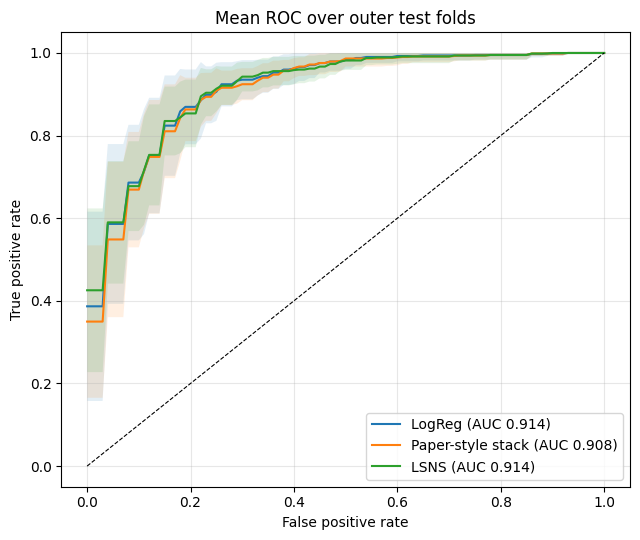

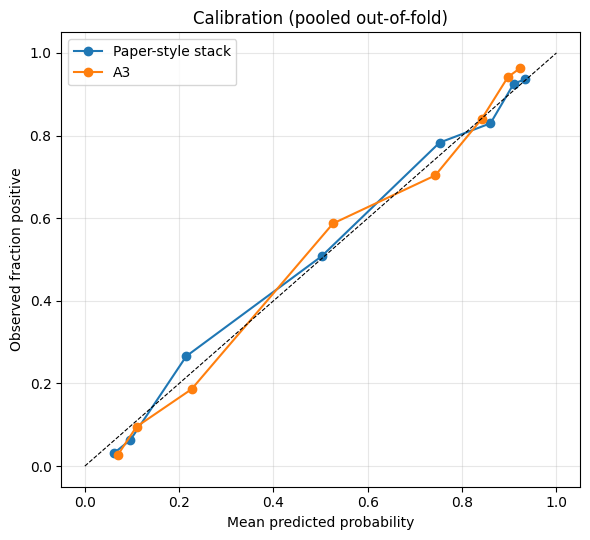

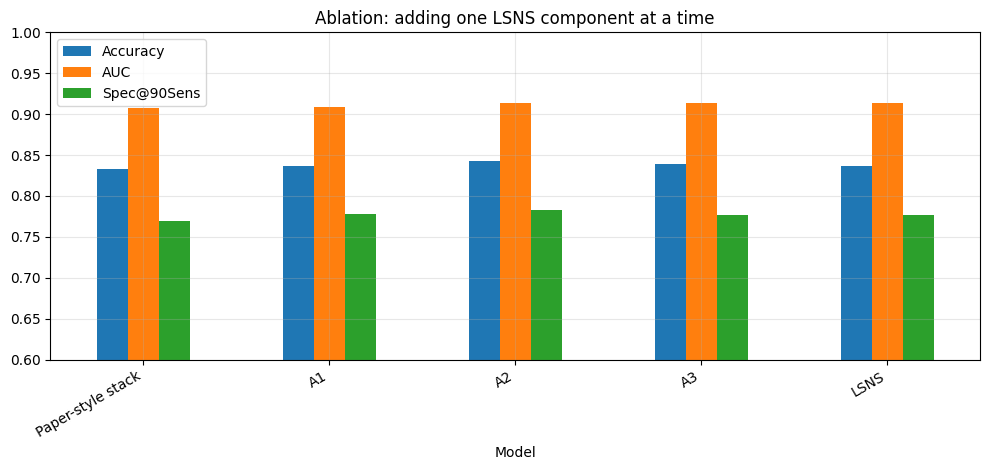

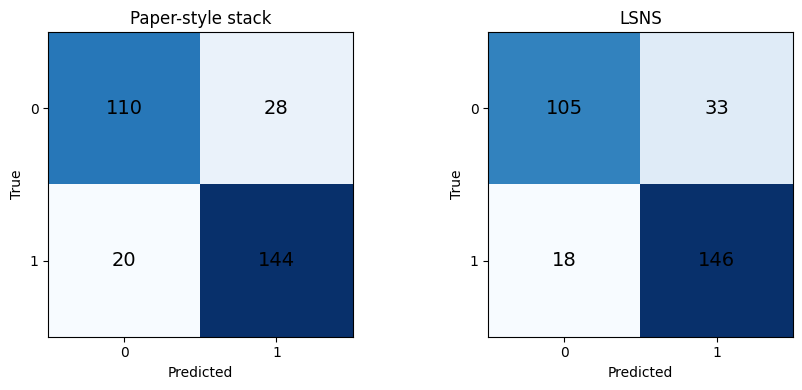

In [24]:
# Figure 1: metric distributions across folds
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
short = {m: m.split(":")[0] if m.startswith("A") else m.replace(" (baseline)", "").replace(" (full, + sens. threshold)", "") for m in order}
for ax, metric in zip(axes, ["Accuracy", "AUC", "Spec@90Sens"]):
    data = [fold_df[fold_df.Model == m][metric].values for m in order]
    ax.boxplot(data, labels=[short[m] for m in order], showmeans=True)
    ax.set_title(metric); ax.tick_params(axis="x", rotation=45); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig1_boxplots.png", dpi=200); plt.show()

# Figure 2: mean ROC with +/-1 std band, selected models
grid = np.linspace(0, 1, 101)
plt.figure(figsize=(6.5, 5.5))
for name in ["LogReg (baseline)", "Paper-style stack", FULL]:
    tprs = []
    for f, s in pred_df[pred_df.Model == name].groupby("fold"):
        fpr, tpr, _ = roc_curve(s.y, s.p); tprs.append(np.interp(grid, fpr, tpr))
    mt, sd = np.mean(tprs, 0), np.std(tprs, 0)
    plt.plot(grid, mt, label=f"{short[name]} (AUC {fold_df[fold_df.Model==name].AUC.mean():.3f})")
    plt.fill_between(grid, np.clip(mt - sd, 0, 1), np.clip(mt + sd, 0, 1), alpha=.12)
plt.plot([0, 1], [0, 1], "k--", lw=.8); plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("Mean ROC over outer test folds"); plt.legend(loc="lower right"); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig2_roc.png", dpi=200); plt.show()

# Figure 3: calibration (pooled out-of-fold predictions)
plt.figure(figsize=(6, 5.5))
for name in ["Paper-style stack", "A3: + nested tuning"]:
    s = pred_df[pred_df.Model == name]
    fr, mp = calibration_curve(s.y, s.p, n_bins=8, strategy="quantile")
    plt.plot(mp, fr, "o-", label=short[name])
plt.plot([0, 1], [0, 1], "k--", lw=.8); plt.xlabel("Mean predicted probability"); plt.ylabel("Observed fraction positive")
plt.title("Calibration (pooled out-of-fold)"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig3_calibration.png", dpi=200); plt.show()

# Figure 4: ablation (accuracy, AUC, Spec@90Sens means)
abl = mean_t.loc[["Paper-style stack", "A1: + clinical features", "A2: + regularised base set",
                  "A3: + nested tuning", FULL], ["Accuracy", "AUC", "Spec@90Sens"]]
ax = abl.plot(kind="bar", figsize=(10, 4.8), ylim=(0.6, 1.0)); ax.set_title("Ablation: adding one LSNS component at a time")
ax.set_xticklabels([short[m] for m in abl.index], rotation=30, ha="right"); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig4_ablation.png", dpi=200); plt.show()

# Figure 5: pooled confusion matrices (paper-style stack vs full LSNS), first repeat only
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
first_repeat_folds = range(N_SPLITS)
for ax, name in zip(axes, ["Paper-style stack", FULL]):
    s = pred_df[(pred_df.Model == name) & (pred_df.fold.isin(first_repeat_folds))]
    cm = confusion_matrix(s.y, s.pred, labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm): ax.text(j, i, v, ha="center", va="center", fontsize=14)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(short[name])
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig5_confusion.png", dpi=200); plt.show()

### 2.10 Feature importance (permutation, on held-out folds)

Permutation importance of the **full LSNS** is computed on the test fold of each outer fold in the first repeat and averaged so it reflects held out data.

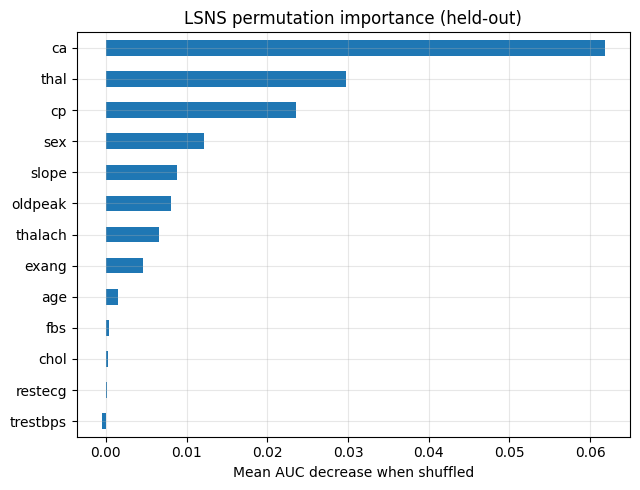

In [25]:
imps = []
for k, (tr, te) in enumerate(outer.split(X, y)):
    if k >= N_SPLITS: break                       # first repeat only
    m = MODELS[FULL]().fit(X.iloc[tr], y[tr])
    r = permutation_importance(m, X.iloc[te], y[te], scoring="roc_auc",
                               n_repeats=10, random_state=SEED)
    imps.append(r.importances_mean)
imp = pd.Series(np.mean(imps, 0), index=X.columns).sort_values()
plt.figure(figsize=(6.5, 5)); imp.plot(kind="barh"); plt.xlabel("Mean AUC decrease when shuffled")
plt.title("LSNS permutation importance (held-out)"); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig6_importance.png", dpi=200); plt.show()
imp.sort_values(ascending=False).round(4).to_csv(f"{OUT_DIR}/permutation_importance.csv")

### 2.11 Final comparison with the paper and the Part 1 reproduction

The first two rows use a different (leaky) protocol so they are **not** directly comparable with the clean protocol rows. That difference is the point of the study.

In [26]:
paper = {"Accuracy": 0.9853, "Precision": 1.0, "Recall": 0.9727, "F1": 0.9861, "AUC": 0.9880}
# Part 1 reproduction numbers: copy them from your Part 1 table (Stacking row)
part1 = {"Accuracy": 1.0, "Precision": 1.0, "Recall": 1.0, "F1": 1.0, "AUC": 1.0}

cols = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
final = pd.DataFrame([paper, part1], index=["Paper (reported, leaky split)", "Part 1 reproduction (leaky split)"])
final = pd.concat([final, mean_t.loc[order, cols]])
display(final.round(4))
final.round(4).to_csv(f"{OUT_DIR}/final_comparison.csv")

,Accuracy,Precision,Recall,F1,AUC
"Paper (reported, leaky split)",0.9853,1.0000,0.9727,0.9861,0.9880
Part 1 reproduction (leaky split),1.0000,1.0000,1.0000,1.0000,1.0000
LogReg (baseline),0.8450,0.8446,0.8828,0.8607,0.9135
RandomForest (baseline),0.8213,0.8317,0.8488,0.8370,0.9085
Paper-style stack,0.8324,0.8392,0.8633,0.8482,0.9079
A1: + clinical features,0.8364,0.8394,0.8694,0.8514,0.9091
A2: + regularised base set,0.8424,0.8384,0.8852,0.8588,0.9135
A3: + nested tuning,0.8390,0.8355,0.8828,0.8560,0.9142
"LSNS (full, + sens. threshold)",0.8371,0.8233,0.8975,0.8565,0.9142


Video demonstration

https://deakin.au.panopto.com/Panopto/Pages/Viewer.aspx?id=8a0f373d-d08c-4aaa-80cd-b4d7006a0588